# Proyecto Centinela · Fase 1 — Línea Base con un MLP
### Sistema de alerta temprana del poder adquisitivo del salario mínimo (Ciudad piloto: Bogotá)

**Autora:** Estefanny Ruíz González_Miguel Alarcón Ojeda
**Curso:** Profundización I — Redes Neuronales / Deep Learning
**Maestría en Ciencia de Datos — Universidad Santo Tomás**

**Problema:** predecir si el poder adquisitivo del salario mínimo legal vigente (SMLV)
**está cayendo** en un mes dado (la variación anual del salario real es negativa),
usando variables macroeconómicas observables.

**Posible Cliente:** analista de política pública / gremio laboral que necesita una señal
de alerta sobre la erosión del poder de compra del salario mínimo.

Este notebook construye la línea base con un Perceptrón Multicapa (MLP) entrenado
desde cero en PyTorch, e incluye: EDA, ingeniería de variables sin fuga de datos,
partición cronológica, entrenamiento explícito, regularización con Dropout y
evaluación con matriz de confusión y discusión ética.


## 0. Preparación del entorno

Importamos las librerías y **fijamos la semilla** para que los resultados sean
reproducibles.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Semilla fija: reproducibilidad
SEMILLA = 42
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

print("PyTorch:", torch.__version__)


PyTorch: 2.11.0+cpu


In [12]:
from google.colab import files
subido = files.upload()

Saving consolidado_bogota.csv to consolidado_bogota (1).csv


## 1. Carga de datos y análisis exploratorio (EDA)

Cargamos la base consolidada de Bogotá (datos mensuales 2000–2026, fuentes: DANE y
Banco de la República). Ordenamos por fecha porque es una **serie temporal** y el
orden importa para todo lo que sigue.


In [13]:
import pandas as pd
df = pd.read_csv("consolidado_bogota.csv")
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)
print("Cargado:", df.shape)
df.head()

Cargado: (324, 8)


,fecha,smlv_nominal,ipc_bogota,trm_promedio,smlv_real,ipc_var_anual,poder_adq_index,smlv_real_var_anual
0,2000-01-01,260100,40.0507,2087.0,649426.85,NaN,100.00,NaN
1,2000-02-01,260100,40.3406,2179.0,644759.87,NaN,99.28,NaN
2,2000-03-01,260100,40.6305,2196.0,640159.49,NaN,98.57,NaN
3,2000-04-01,260100,40.9205,2186.0,635622.73,NaN,97.87,NaN
4,2000-05-01,260100,41.2104,2106.0,631151.36,NaN,97.19,NaN


In [14]:
RUTA = "consolidado_bogota.csv"

df = pd.read_csv(RUTA)
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)

print("Dimensiones:", df.shape)
print("Rango de fechas:", df['fecha'].min().date(), "->", df['fecha'].max().date())
df.head()

Dimensiones: (324, 8)
Rango de fechas: 2000-01-01 -> 2026-12-01


,fecha,smlv_nominal,ipc_bogota,trm_promedio,smlv_real,ipc_var_anual,poder_adq_index,smlv_real_var_anual
0,2000-01-01,260100,40.0507,2087.0,649426.85,NaN,100.00,NaN
1,2000-02-01,260100,40.3406,2179.0,644759.87,NaN,99.28,NaN
2,2000-03-01,260100,40.6305,2196.0,640159.49,NaN,98.57,NaN
3,2000-04-01,260100,40.9205,2186.0,635622.73,NaN,97.87,NaN
4,2000-05-01,260100,41.2104,2106.0,631151.36,NaN,97.19,NaN


In [15]:
# Valores faltantes por columna
print("Valores faltantes por columna:")
print(df.isna().sum())


Valores faltantes por columna:
fecha                   0
smlv_nominal            0
ipc_bogota              0
trm_promedio            7
smlv_real               0
ipc_var_anual          12
poder_adq_index         0
smlv_real_var_anual    12
dtype: int64


### 1.1 Construcción de la variable objetivo (etiqueta)

Definimos el **evento de riesgo**: `riesgo = 1` cuando la variación anual del salario
mínimo **real** es negativa (el poder adquisitivo cae respecto al mismo mes del año
anterior); `riesgo = 0` en caso contrario.


In [16]:
df['riesgo'] = (df['smlv_real_var_anual'] < 0).astype(int)

# Distribución de clases
conteo = df['riesgo'].value_counts().sort_index()
print("Distribución de clases:")
print(conteo)
print(f"Proporción de la clase de riesgo: {df['riesgo'].mean():.1%}")


Distribución de clases:
riesgo
0    294
1     30
Name: count, dtype: int64
Proporción de la clase de riesgo: 9.3%


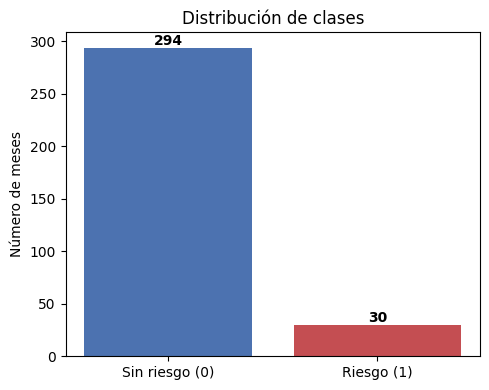

In [17]:
import matplotlib.pyplot as plt

# Gráfica 1: distribución de clases
plt.figure(figsize=(5,4))
plt.bar(['Sin riesgo (0)', 'Riesgo (1)'], conteo.values,
        color=['#4C72B0', '#C44E52'])
plt.title('Distribución de clases')
plt.ylabel('Número de meses')
for i, v in enumerate(conteo.values):
    plt.text(i, v + 3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Hallazgo clave del EDA:** las clases están **fuertemente desbalanceadas**
(solo ~9.3 % de los meses son de riesgo). Esto tiene sentido económico —el salario
real rara vez cae— pero condiciona la evaluación: **la exactitud global engaña**
(un modelo que diga siempre "sin riesgo" acertaría ~90.7 %). Por eso más adelante
priorizamos el *recall* y el F1 de la clase de riesgo, no la exactitud.


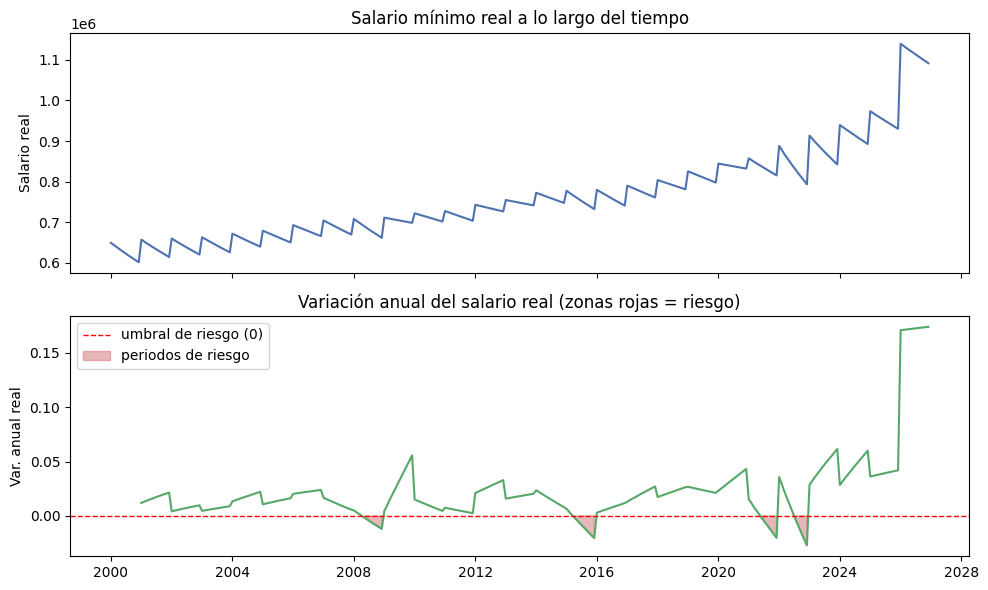

In [18]:
# Gráfica 2: evolución del salario real y su variación anual en el tiempo
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(df['fecha'], df['smlv_real'], color='#4C72B0')
ax[0].set_ylabel('Salario real')
ax[0].set_title('Salario mínimo real a lo largo del tiempo')

ax[1].plot(df['fecha'], df['smlv_real_var_anual'], color='#55A868')
ax[1].axhline(0, color='red', linestyle='--', linewidth=1, label='umbral de riesgo (0)')
ax[1].fill_between(df['fecha'], df['smlv_real_var_anual'], 0,
                   where=(df['smlv_real_var_anual'] < 0),
                   color='#C44E52', alpha=0.4, label='periodos de riesgo')
ax[1].set_ylabel('Var. anual real')
ax[1].set_title('Variación anual del salario real (zonas rojas = riesgo)')
ax[1].legend()
plt.tight_layout()
plt.show()


**Segundo hallazgo:** los periodos de riesgo (zonas rojas) se **concentran en
años históricos**: En 2**2009,** la variación cayó por debajo de cero debido al coletazo de la crisis financiera global y una inflación acumulada previa que superó el ajuste salarial decretado. En **2016**,  La caída por debajo de cero fue aún más pronunciada debido a que la inflación en Colombia se disparó hasta el \(5,75\%\) (impulsada por el Fenómeno del Niño y la devaluación del peso), superando el poder de compra del salario mínimo de ese año. Entre **2021-2022**, la gráfica muestra otras dos fuertes caídas en la zona de riesgo, ocasionadas por la alta inflación global y local post-pandemia.

En los años recientes el salario mínimo subió más que la
inflación, así que casi no hay caídas.
Esto será determinante para la partición.


## 2. Ingeniería de variables (sin fuga de datos)

Esta es la decisión más importante del proyecto, así que la justificamos:

**¿Por qué no usamos las variables en su nivel crudo?** Probamos la correlación del
IPC, la TRM y el salario nominal (en nivel) con la etiqueta: resultó casi nula
(±0.06). Económicamente tiene sentido —el *nivel* del IPC en un mes no dice si el
salario real cae; lo que importa es la **dinámica** (qué tan rápido cambian los
precios).

**Variables que sí usamos (features de dinámica):**
- `ipc_mom`: variación mensual del IPC (aceleración de precios a corto plazo).
- `ipc_mom3`: variación trimestral del IPC.
- `brecha_yoy`: diferencia entre el crecimiento anual del salario nominal y la
  inflación anual. Es la lógica central del problema: el salario real cae cuando
  el nominal crece **menos** que los precios.

**Exclusión por fuga de datos (*data leakage*).** Excluimos `smlv_real`,
`smlv_real_var_anual` (son la base de la etiqueta) y también `poder_adq_index`
(verificamos que es `smlv_real` reescalado a base 100). Incluirlas sería darle la
respuesta al modelo.


In [20]:
# Justificación cuantitativa: niveles crudos vs. features de dinámica
niveles  = ['smlv_nominal', 'ipc_bogota', 'trm_promedio', 'ipc_var_anual']
dinamica = ['ipc_mom', 'ipc_mom3', 'brecha_yoy']

print("Correlación con la etiqueta 'riesgo':\n")
print("--- Niveles crudos (señal débil) ---")
for v in niveles:
    c = df[[v, 'riesgo']].dropna().corr().iloc[0, 1]
    print(f"  {v:16s}: {c:+.3f}")

print("\n--- Features de dinámica (señal útil) ---")
for v in dinamica:
    c = df[[v, 'riesgo']].dropna().corr().iloc[0, 1]
    print(f"  {v:16s}: {c:+.3f}")

Correlación con la etiqueta 'riesgo':

--- Niveles crudos (señal débil) ---
  smlv_nominal    : +0.033
  ipc_bogota      : +0.081
  trm_promedio    : +0.159
  ipc_var_anual   : +0.253

--- Features de dinámica (señal útil) ---
  ipc_mom         : +0.326
  ipc_mom3        : +0.342
  brecha_yoy      : -0.327


In [19]:
# Features de dinámica (cambios, no niveles)
df['ipc_mom']    = df['ipc_bogota'].pct_change(1)     # variación mensual del IPC
df['ipc_mom3']   = df['ipc_bogota'].pct_change(3)     # variación trimestral del IPC
df['nom_yoy']    = df['smlv_nominal'].pct_change(12)  # crecimiento anual del salario nominal
df['brecha_yoy'] = df['nom_yoy'] - df['ipc_var_anual']  # brecha nominal - inflación

FEATURES = ['ipc_mom', 'ipc_mom3', 'brecha_yoy']

# Verificación de señal: correlación de cada feature con la etiqueta
print("Correlación de cada feature con la etiqueta 'riesgo':")
for f in FEATURES:
    c = df[[f, 'riesgo']].dropna().corr().iloc[0, 1]
    print(f"  {f:12s}: {c:+.3f}")


Correlación de cada feature con la etiqueta 'riesgo':
  ipc_mom     : +0.326
  ipc_mom3    : +0.342
  brecha_yoy  : -0.327


In [21]:
# Eliminamos filas con faltantes en las features (primeros meses sin historial)
data = df.dropna(subset=FEATURES + ['smlv_real_var_anual']).reset_index(drop=True)
print("Filas utilizables tras crear las features:", len(data))
print("Balance de clases en datos utilizables:", round(data['riesgo'].mean(), 3))


Filas utilizables tras crear las features: 312
Balance de clases en datos utilizables: 0.096


## 3. Partición cronológica 70 / 15 / 15

Como es una **serie temporal**, NO repartimos al azar: el modelo no debe entrenar
con meses más recientes que los que usa para validar o probar (eso sería "ver el
futuro", una fuga temporal). Cortamos **en orden de fecha**, siguiendo la proporción
70/15/15 sugerida por el docente.


In [22]:
n = len(data)
i_train = int(n * 0.70)
i_val   = int(n * 0.85)

train = data.iloc[:i_train]
val   = data.iloc[i_train:i_val]
test  = data.iloc[i_val:]

print(f"train: {len(train)} filas | {train['fecha'].min().date()} -> {train['fecha'].max().date()}")
print(f"val  : {len(val)} filas | {val['fecha'].min().date()} -> {val['fecha'].max().date()}")
print(f"test : {len(test)} filas | {test['fecha'].min().date()} -> {test['fecha'].max().date()}")
print()
print("Casos de riesgo por conjunto:")
print(f"  train: {train['riesgo'].sum()} | val: {val['riesgo'].sum()} | test: {test['riesgo'].sum()}")


train: 218 filas | 2001-01-01 -> 2019-02-01
val  : 47 filas | 2019-03-01 -> 2023-01-01
test : 47 filas | 2023-02-01 -> 2026-12-01

Casos de riesgo por conjunto:
  train: 17 | val: 13 | test: 0


**Decisión metodológica** Como los periodos de
riesgo se concentran en el pasado, el conjunto de **test** (años más recientes)
queda **sin casos positivos**. Una matriz de confusión sin positivos no permite
medir si el modelo detecta el riesgo. Por eso, conservando el orden cronológico,
**reportamos las métricas de detección sobre el conjunto de validación**, que sí
contiene casos de riesgo. Esta es una limitación real de los datos, no un error de
diseño, y se discute en el informe.


In [23]:
# Escalado: ajustamos el scaler SOLO con train y lo aplicamos a val/test
scaler = StandardScaler()
X_train = scaler.fit_transform(train[FEATURES])
X_val   = scaler.transform(val[FEATURES])
X_test  = scaler.transform(test[FEATURES])

y_train = train['riesgo'].values
y_val   = val['riesgo'].values
y_test  = test['riesgo'].values

# Convertimos a tensores de PyTorch
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val,   dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)

# La etiqueta debe ser float y con forma (N, 1), igual que el logit de salida
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val   = torch.tensor(y_val,   dtype=torch.float32).view(-1, 1)
y_test  = torch.tensor(y_test,  dtype=torch.float32).view(-1, 1)

n_feat = X_train.shape[1]
print("Número de variables de entrada (n_feat):", n_feat)
print("Formas -> X_train:", tuple(X_train.shape), "| y_train:", tuple(y_train.shape))


Número de variables de entrada (n_feat): 3
Formas -> X_train: (218, 3) | y_train: (218, 1)


## 4. Diseño de la arquitectura (MLP)

Definimos un MLP con **dos capas ocultas** y activación **ReLU**. La salida es una
sola neurona **sin activación** (un *logit*): la sigmoide NO va dentro del modelo,
porque la combinamos con la pérdida en el siguiente paso por estabilidad numérica.

- **ReLU** en las capas ocultas: introduce la no-linealidad. Sin ella, apilar capas
  equivaldría a una sola transformación lineal y la red no podría aprender patrones
  complejos.
- **Salida = logit** (no sigmoide aquí): evita el antipatrón de la "doble sigmoide".


In [24]:
class MLP(nn.Module):
    def __init__(self, n_feat, p_dropout=0.0):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(n_feat, 16),  # capa oculta 1
            nn.ReLU(),
            nn.Dropout(p_dropout),  # apaga neuronas al azar (regularización)
            nn.Linear(16, 8),       # capa oculta 2
            nn.ReLU(),
            nn.Dropout(p_dropout),
            nn.Linear(8, 1)         # salida: 1 logit (sin sigmoide)
        )

    def forward(self, x):
        return self.red(x)  # devuelve el logit; la sigmoide se aplica en evaluación


## 5. Configuración y bucle de entrenamiento

- **Pérdida:** `BCEWithLogitsLoss` — combina sigmoide + entropía cruzada binaria en
  un solo paso numéricamente estable. Recibe el *logit* directamente.
- **Desbalance:** usamos `pos_weight` para que la pérdida penalice más los errores
  sobre la clase de riesgo (minoritaria). Sin esto, el modelo tiende a ignorarla.
- **Optimizador:** Adam, tasa de aprendizaje 0.01.
- **Bucle explícito:** 50 épocas con el ciclo
  `zero_grad → forward → pérdida → backward → step`.

Guardamos las pérdidas de train y val en cada época para graficar las curvas.


In [25]:
def entrenar(modelo, X_train, y_train, X_val, y_val, epocas=50, lr=0.01, usar_pos_weight=True):
    # Peso para la clase positiva (minoritaria): n_negativos / n_positivos
    if usar_pos_weight:
        n_pos = y_train.sum().item()
        n_neg = len(y_train) - n_pos
        pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32)
    else:
        pos_weight = None

    criterio = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optim = torch.optim.Adam(modelo.parameters(), lr=lr)

    hist_train, hist_val = [], []
    for epoca in range(epocas):
        # --- entrenamiento ---
        modelo.train()
        optim.zero_grad()                      # 1. limpia gradientes previos
        logits = modelo(X_train)               # 2. forward (devuelve logits)
        perdida = criterio(logits, y_train)    # 3. cálculo del error
        perdida.backward()                     # 4. backward (retropropagación)
        optim.step()                           # 5. actualiza los pesos

        # --- validación (sin actualizar pesos) ---
        modelo.eval()
        with torch.no_grad():
            perdida_val = criterio(modelo(X_val), y_val)

        hist_train.append(perdida.item())
        hist_val.append(perdida_val.item())

        if epoca % 10 == 0:
            print(f"Época {epoca:2d} | pérdida train: {perdida.item():.4f} | val: {perdida_val.item():.4f}")

    return hist_train, hist_val


In [26]:
# Modelo base (sin Dropout) — esperamos que tienda a sobreajustar
torch.manual_seed(SEMILLA)
modelo_base = MLP(n_feat, p_dropout=0.0)
print("=== Entrenando modelo base (sin regularización) ===")
ht_base, hv_base = entrenar(modelo_base, X_train, y_train, X_val, y_val, epocas=50, lr=0.01)


=== Entrenando modelo base (sin regularización) ===
Época  0 | pérdida train: 1.2539 | val: 2.8510
Época 10 | pérdida train: 0.9050 | val: 1.8324
Época 20 | pérdida train: 0.5002 | val: 1.2695
Época 30 | pérdida train: 0.2269 | val: 1.7294
Época 40 | pérdida train: 0.1083 | val: 2.2960


## 6. Experimentación y regularización (Dropout)

Ahora entrenamos un segundo modelo **idéntico pero con Dropout** (apaga el 30 % de
las neuronas al azar en cada paso, forzando representaciones más robustas) y
comparamos las curvas de pérdida. El objetivo es mostrar el sobreajuste del modelo
base y cómo la regularización lo mitiga.


In [27]:
# Modelo con Dropout
torch.manual_seed(SEMILLA)
modelo_dropout = MLP(n_feat, p_dropout=0.30)
print("=== Entrenando modelo con Dropout (p=0.30) ===")
ht_drop, hv_drop = entrenar(modelo_dropout, X_train, y_train, X_val, y_val, epocas=50, lr=0.01)


=== Entrenando modelo con Dropout (p=0.30) ===
Época  0 | pérdida train: 1.2910 | val: 2.8634
Época 10 | pérdida train: 1.0216 | val: 1.8211
Época 20 | pérdida train: 0.6603 | val: 1.2155
Época 30 | pérdida train: 0.5326 | val: 1.4779
Época 40 | pérdida train: 0.4038 | val: 1.6651


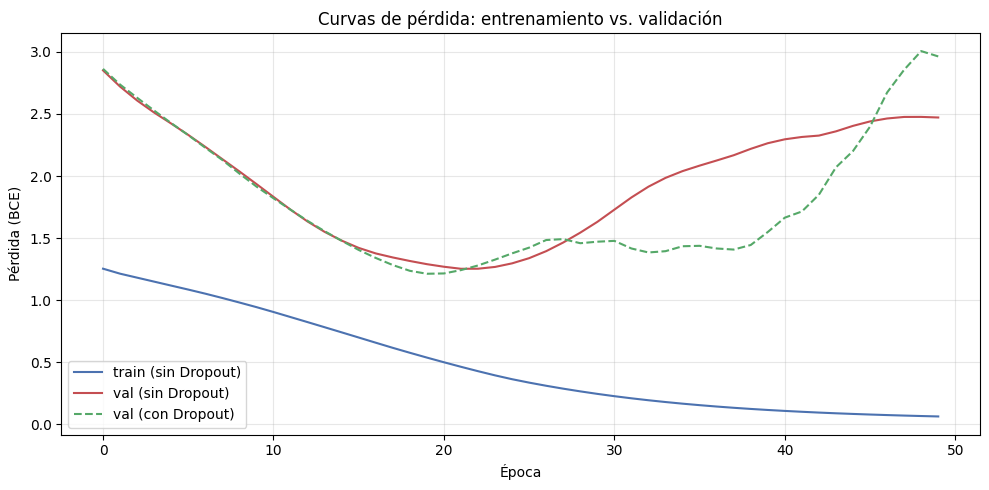

In [28]:
# Curvas de pérdida: train vs val, sin y con Dropout
plt.figure(figsize=(10, 5))
plt.plot(ht_base, label='train (sin Dropout)', color='#4C72B0')
plt.plot(hv_base, label='val (sin Dropout)', color='#C44E52')
plt.plot(hv_drop, label='val (con Dropout)', color='#55A868', linestyle='--')
plt.xlabel('Época')
plt.ylabel('Pérdida (BCE)')
plt.title('Curvas de pérdida: entrenamiento vs. validación')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Cómo leer la gráfica.** Si la pérdida de *train* sigue bajando mientras la de
*val* deja de bajar o sube, hay **sobreajuste**: el modelo memoriza el entrenamiento
pero generaliza peor. El punto donde la curva de validación deja de mejorar marca la
época óptima (*early stopping* como criterio de selección). La curva de validación
**con Dropout** debería mantenerse más estable. *(Se Comenta en el informe la época
concreta donde se observa el cruce, según el resultado que salga.)*


## 7. Evaluación, matriz de confusión y métricas

Evaluamos sobre el conjunto de **validación** (que sí contiene casos de riesgo).
Como el modelo devuelve un *logit*, aplicamos `torch.sigmoid` para obtener la
probabilidad y la umbralizamos en 0.5 para decidir la clase.


In [29]:
def evaluar(modelo, X, y_true, nombre="validación"):
    modelo.eval()
    with torch.no_grad():
        prob = torch.sigmoid(modelo(X))          # logit -> probabilidad
        pred = (prob >= 0.5).int().view(-1).numpy()
    y_true = y_true.int().view(-1).numpy()

    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    prec = precision_score(y_true, pred, zero_division=0)
    rec  = recall_score(y_true, pred, zero_division=0)
    f1   = f1_score(y_true, pred, zero_division=0)

    print(f"=== Evaluación sobre {nombre} ===")
    print("Matriz de confusión [filas=real, columnas=predicho]:")
    print(cm)
    print(f"Precisión (clase riesgo): {prec:.3f}")
    print(f"Recall   (clase riesgo): {rec:.3f}")
    print(f"F1       (clase riesgo): {f1:.3f}")
    return cm, pred

cm, pred = evaluar(modelo_dropout, X_val, y_val, "validación")


=== Evaluación sobre validación ===
Matriz de confusión [filas=real, columnas=predicho]:
[[33  1]
 [ 2 11]]
Precisión (clase riesgo): 0.917
Recall   (clase riesgo): 0.846
F1       (clase riesgo): 0.880


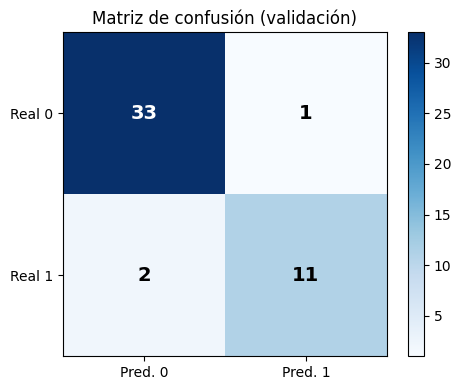

In [30]:
# Visualización de la matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred. 0', 'Pred. 1'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Real 0', 'Real 1'])
ax.set_title('Matriz de confusión (validación)')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black',
                fontsize=14, fontweight='bold')
plt.colorbar(im)
plt.tight_layout()
plt.show()


## 8. Análisis de errores y auditoría ética

En un sistema de **alerta temprana**, los dos tipos de error tienen costos muy
distintos para el cliente:

- **Falso negativo (FN):** el modelo dice "sin riesgo" cuando el poder adquisitivo
  **sí** está cayendo. Es el error **más costoso**: el tomador de decisiones no
  recibe la alerta y la pérdida de bienestar de los hogares ocurre sin que nadie la
  prevenga.
- **Falso positivo (FP):** el modelo alerta de una caída que no ocurre. Genera un
  costo menor pero real: decisiones de ajuste o alarma sin fundamento, y desgaste de
  la credibilidad del sistema si se repite.

Para este cliente, **priorizamos minimizar los falsos negativos** (maximizar el
*recall* de la clase de riesgo), aun a costa de algunos falsos positivos. Por eso
usamos `pos_weight` en la pérdida. Esta decisión se ancla en el **Marco Ético para
la IA en Colombia (Minciencias, 2021)**, que enfatiza valorar el impacto real sobre
las personas por encima de la exactitud agregada.



## 9. Guardar el modelo

Guardamos los pesos del modelo final para poder reutilizarlo sin reentrenar
(útil porque Colab puede desconectarse).


In [ ]:
torch.save(modelo_dropout.state_dict(), "centinela_fase1.pt")
print("Modelo guardado como centinela_fase1.pt")


---

### Resumen del notebook

1. **EDA** → detectó desbalance (9.6 %) y concentración histórica del riesgo.
2. **Features** → de dinámica (no niveles), sin fuga de datos.
3. **Partición** → cronológica 70/15/15; evaluación en validación (test sin positivos).
4. **MLP** → 2 capas ocultas ReLU, salida logit, `BCEWithLogitsLoss` con `pos_weight`.
5. **Regularización** → comparación sin/con Dropout en las curvas de pérdida.
6. **Evaluación** → matriz de confusión y métricas por clase.
7. **Ética** → priorización de falsos negativos, anclada al Marco Ético de Minciencias.

**Limitaciones:** muestra pequeña (~312 meses), una sola ciudad (Bogotá), y datos de
2026 parcialmente proyectados.
